# Task3 assignment data2

### Theory Discussion

**PyTorch**

PyTorch is a popular open-source deep learning library developed by Meta. It makes it easier to build, train, and evaluate machine learning models using tensors and automatic differentiation. One of its biggest advantages is its flexible and intuitive design, which allows developers and researchers to experiment with models efficiently.

**Regression**

Regression is a supervised machine learning approach used to understand and predict numerical values. The main objective is to learn the relationship between input features and a target variable. Once the relationship is learned from historical data, the model can estimate outputs for unseen inputs.

**Why PyTorch for Regression?**

PyTorch provides built-in tools for creating custom models, defining loss functions, and optimizing model parameters. These features make it suitable for implementing regression algorithms and analyzing model performance through training and testing processes.


## TASK 3: {DATASET = assignment-data2.csv}

### Data Preparation

In [238]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [239]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

### Train-Test Split

In [240]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed that the dataset is properly splitted into training and testing sets.

### Data Visualization Function

In [241]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

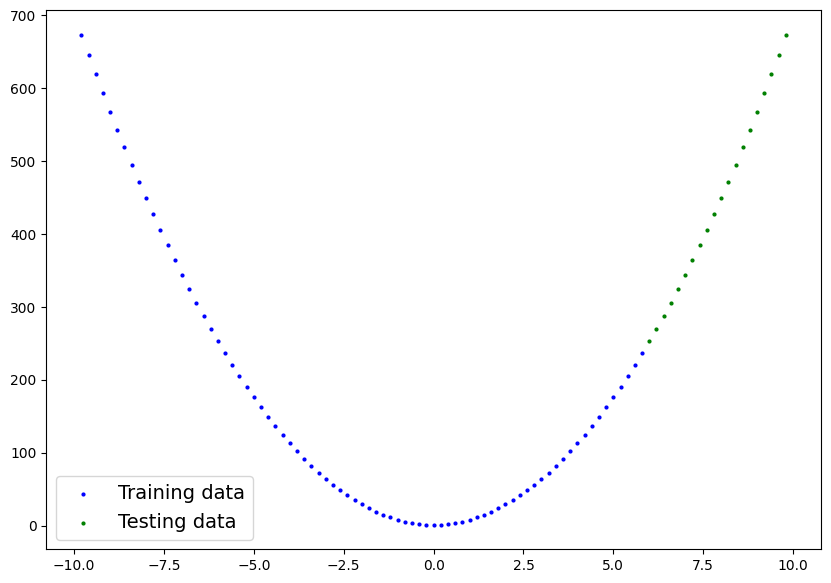

In [242]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function plots training data (blue), test data (green).

### Observation Scatter plot showing dataset distribution helps visually understand pattern (quadratic curve)

### Algorithm Selection

We define a custom model:

y=ax2+bx+c

### Discussion These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [243]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [244]:
model_0 = QuadraticRegressionModel()

In [245]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [246]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789]])

### Discussion

Here, the predictions are made without gradient tracking. It is used for only evaluation purpose.

### Observation

Predictions are inaccurate initially.

In [247]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[13.1282],
        [13.9755],
        [14.8497],
        [15.7508],
        [16.6789],
        [17.6340],
        [18.6159],
        [19.6248],
        [20.6606],
        [21.7234],
        [22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


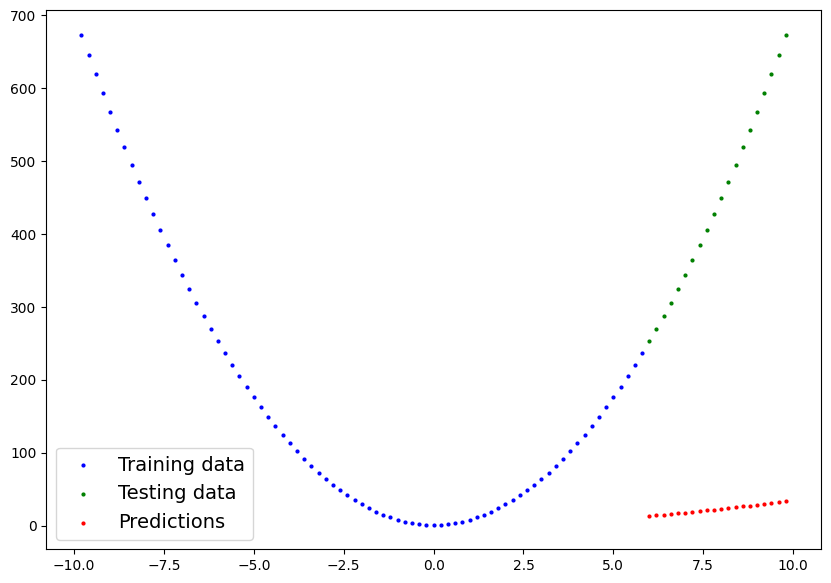

In [248]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [249]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### Discussion

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [250]:

torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 166.2732391357422 | MAE Test Loss: 408.8077697753906 
Epoch: 10 | MAE Train Loss: 104.26924896240234 | MAE Test Loss: 252.2126007080078 
Epoch: 20 | MAE Train Loss: 42.265235900878906 | MAE Test Loss: 95.61738586425781 
Epoch: 30 | MAE Train Loss: 2.1109044551849365 | MAE Test Loss: 6.325655937194824 
Epoch: 40 | MAE Train Loss: 1.2364046573638916 | MAE Test Loss: 8.994148254394531 
Epoch: 50 | MAE Train Loss: 1.0613176822662354 | MAE Test Loss: 9.8119478225708 
Epoch: 60 | MAE Train Loss: 1.1207554340362549 | MAE Test Loss: 10.009692192077637 
Epoch: 70 | MAE Train Loss: 0.8819864988327026 | MAE Test Loss: 10.844189643859863 
Epoch: 80 | MAE Train Loss: 0.9476461410522461 | MAE Test Loss: 10.903528213500977 
Epoch: 90 | MAE Train Loss: 1.4739694595336914 | MAE Test Loss: 9.812562942504883 
Epoch: 100 | MAE Train Loss: 1.0053342580795288 | MAE Test Loss: 11.123374938964844 
Epoch: 110 | MAE Train Loss: 0.6294490098953247 | MAE Test Loss: 12.171618461608887 
E

### Observation

- Loss decreases over time.

- Model gradually learns correct curve


### Loss Curve Visualization

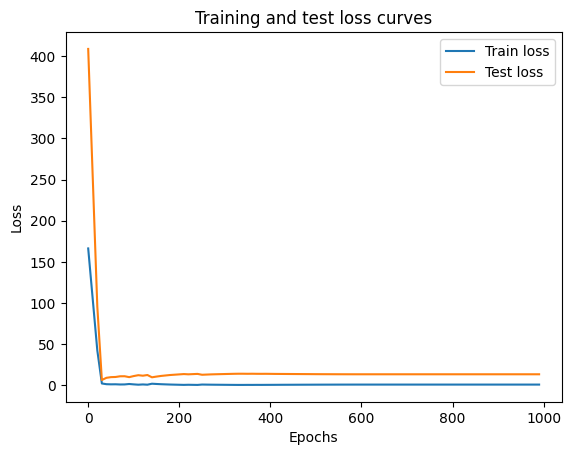

In [251]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### Discussion

The curves shows training vs testing error which help to verify machine learning.

### Observation

The decreasing curve shows that the model is learning.


### Final Prediction Visualization

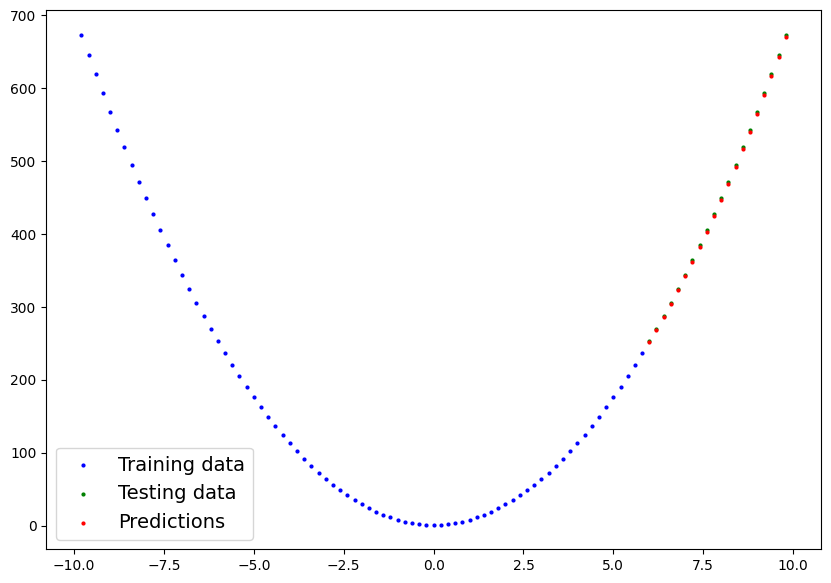

In [252]:

# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

--> The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship

###  Discussion

In this lab, we used PyTorch to build and train a regression model. The dataset was prepared and divided into training and testing sets. The model learned the relationship between variables by adjusting its weight and bias parameters using SGD, while MAE was used to measure prediction errors. As training progressed, the loss decreased, indicating improved performance. The final predictions closely matched the actual values, showing that the model successfully learned the underlying pattern in the data.

### Conclusion

In this lab, we trained regression models using PyTorch and observed how the models improved during the training process. The continuous reduction in loss values indicated that the models were learning effectively from the data. By the end of training, the predicted outputs were very close to the actual values, demonstrating the accuracy and reliability of the regression models.
